<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/CGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset
from torch_geometric.explain.config import (ModelConfig)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Using cached pymatgen-2026.5.4-py3-none-any.whl.metadata (12 kB)
  Using cached pymatgen_core-2026.4.16-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached monty-2026.2.18-py3-none-any.whl.metadata (3.3 kB)
  Using cached palettable-3.3.3-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached spglib-2.7.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached bibtexparser-1.4.4.tar.gz (55 kB)
  Preparing metadata (setup.py) ... done
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached ruamel_yaml-0.19.1-py3-none-any.whl.metadata (16 kB)
Using cached torch_geometric-2.7.0

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

# Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [3]:
print("Total samples:", len(df))

Total samples: 9668


In [4]:
#Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [5]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


In [6]:
os.path.exists(df['cif_path'].iloc[0])

True

# Data Splitting

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


# Feature Extraction

In [8]:
# Node features
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]

# Global Features
def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Train Features for Scaling

In [9]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


In [10]:
# SCALING
node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [11]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [12]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []
    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)
        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u
    return data

In [13]:
def build_and_save(df_split, split_name):
    print(f"Building {split_name} graphs")

    save_dir = os.path.join(GRAPH_DIR, split_name)
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        graph_path = os.path.join(save_dir, f"{row['mp_material_id']}.pt")

        if os.path.exists(graph_path):
            continue

        try:
            graph = build_graph(row)
            torch.save(graph, graph_path)
        except Exception as e:
            print(f"Error: {row['mp_material_id']} | {e}")


# BUILD GRAPHS PER SPLIT
build_and_save(train_df, "Train")
build_and_save(val_df, "Val")
build_and_save(test_df, "Test")

Building Train graphs


100%|██████████| 6767/6767 [00:29<00:00, 229.13it/s] 


Building Val graphs


100%|██████████| 1450/1450 [00:00<00:00, 2514.20it/s]


Building Test graphs


100%|██████████| 1451/1451 [00:00<00:00, 2538.69it/s]


# CharlesCGCNN Model

In [14]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

In [15]:
# Initialize model
model = CharlesCGCNN(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

In [16]:
# Training Configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [17]:
# Graph Dataset Loader
import torch
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

# allow PyG objects
torch.serialization.add_safe_globals([Data, DataEdgeAttr])


class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return data

In [18]:
train_dataset = CrystalDataset(os.path.join(GRAPH_DIR, "Train"))
val_dataset   = CrystalDataset(os.path.join(GRAPH_DIR, "Val"))
test_dataset  = CrystalDataset(os.path.join(GRAPH_DIR, "Test"))

In [19]:
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [20]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [21]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Tracking
train_losses = []
val_losses = []
val_f1_scores = []
val_roc_scores = []

In [22]:
# training function
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)

        # Ensure correct shape
        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [23]:
# validation function
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)

            y = data.y.float().view(-1, 1)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [24]:
# training loop
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch(train_loader)
    val_loss, val_f1, val_roc = eval_epoch(val_loader)

    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    val_roc_scores.append(val_roc)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 31.7376 | Val: 3.1820 | F1: 0.5660 | ROC: 0.6579
Epoch 002 | Train: 3.7984 | Val: 2.1333 | F1: 0.2217 | ROC: 0.6156
Epoch 003 | Train: 0.6962 | Val: 0.9047 | F1: 0.6828 | ROC: 0.7614
Epoch 004 | Train: 0.9328 | Val: 0.6821 | F1: 0.7377 | ROC: 0.7893
Epoch 005 | Train: 0.5420 | Val: 0.7223 | F1: 0.7625 | ROC: 0.8026
Epoch 006 | Train: 0.5023 | Val: 0.8842 | F1: 0.6815 | ROC: 0.7323
Epoch 007 | Train: 0.4965 | Val: 0.5860 | F1: 0.7730 | ROC: 0.8516
Epoch 008 | Train: 0.4975 | Val: 0.5623 | F1: 0.7763 | ROC: 0.8441
Epoch 009 | Train: 0.4820 | Val: 0.5416 | F1: 0.7647 | ROC: 0.8402
Epoch 010 | Train: 0.4903 | Val: 0.5231 | F1: 0.7796 | ROC: 0.8577
Epoch 011 | Train: 0.4633 | Val: 0.5081 | F1: 0.7801 | ROC: 0.8533
Epoch 012 | Train: 0.5521 | Val: 0.5134 | F1: 0.7532 | ROC: 0.8437
Epoch 013 | Train: 0.4822 | Val: 0.4848 | F1: 0.7912 | ROC: 0.8618
Epoch 014 | Train: 0.4720 | Val: 0.5005 | F1: 0.7953 | ROC: 0.8631
Epoch 015 | Train: 0.4620 | Val: 0.4870 | F1: 0.7914 | ROC: 0

In [25]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# Evaluation

In [26]:
def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [27]:
# load best model
model.load_state_dict(torch.load("best_model.pt"))
labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8567
F1-score : 0.8508
ROC-AUC  : 0.9211
              precision    recall  f1-score   support

         0.0       0.89      0.83      0.86       780
         1.0       0.82      0.88      0.85       671

    accuracy                           0.86      1451
   macro avg       0.86      0.86      0.86      1451
weighted avg       0.86      0.86      0.86      1451



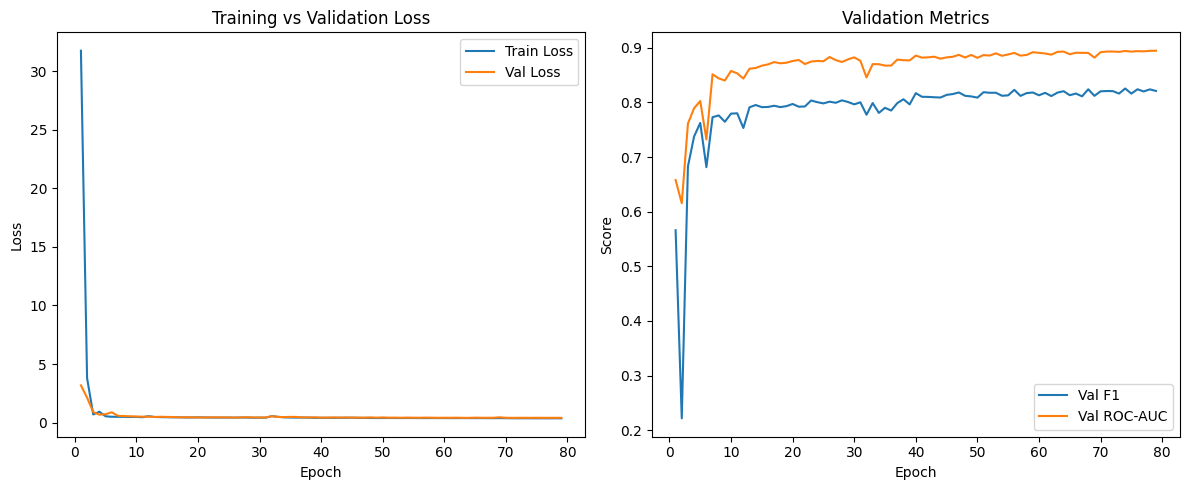

In [28]:
# training curves and validation metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

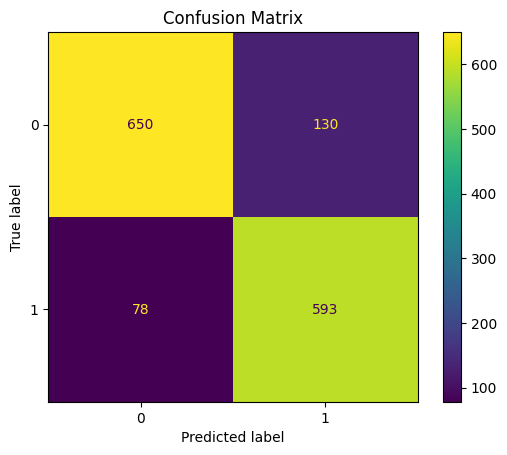

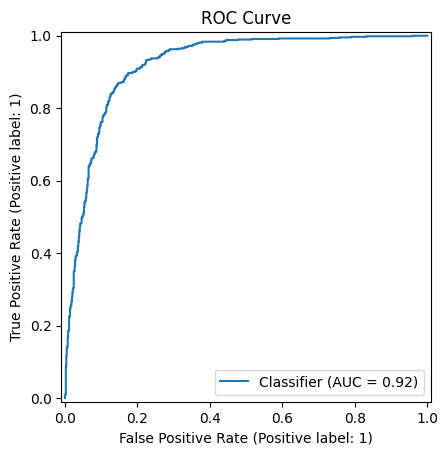

In [29]:
# confunsion matrix
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve")
plt.show()

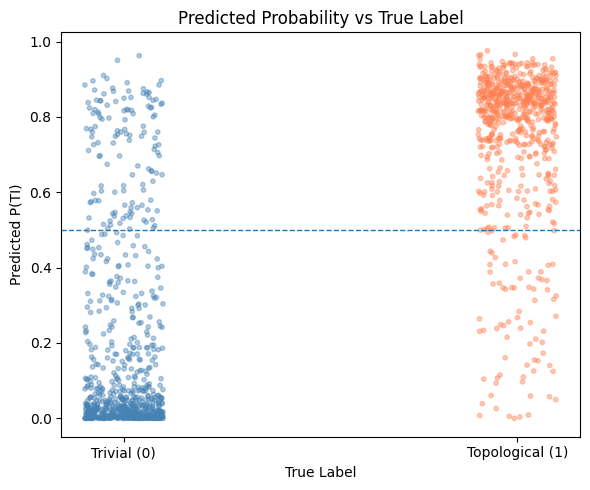

In [30]:
# scatter plot
plt.figure(figsize=(6, 5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels))

colors = ['steelblue' if l == 0 else 'coral' for l in labels]

plt.scatter(labels + jitter, probs, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xticks([0, 1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel('True Label')
plt.ylabel('Predicted P(TI)')
plt.title('Predicted Probability vs True Label')

plt.tight_layout()
plt.show()

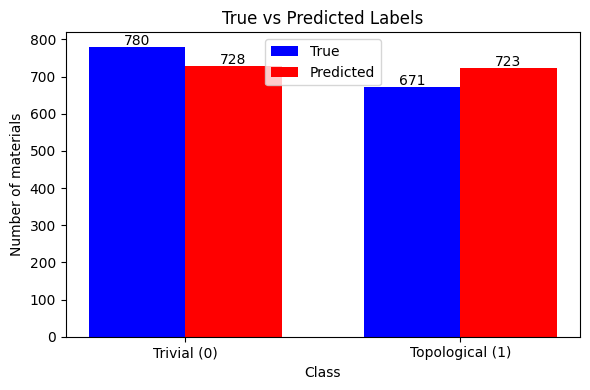

In [31]:
categories = ['Trivial (0)', 'Topological (1)']

true_counts = [(labels == 0).sum(), (labels == 1).sum()]
pred_counts = [(binary == 0).sum(), (binary == 1).sum()]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width/2, true_counts, width, label='True', color='blue')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted', color='red')

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center')

plt.xticks(x, categories)
plt.xlabel('Class')
plt.ylabel('Number of materials')
plt.title('True vs Predicted Labels')
plt.legend()

plt.tight_layout()
plt.show()

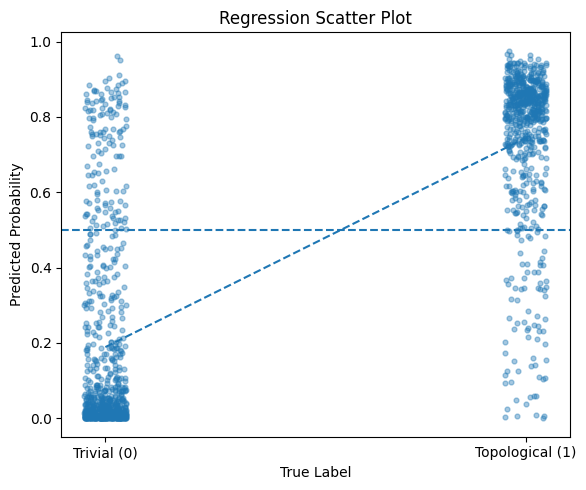

In [33]:
# Regresssion scatter plot
def plot_regression_scatter(labels, probs):
    plt.figure(figsize=(6,5))

    # jitter for visibility
    jitter = np.random.uniform(-0.05, 0.05, size=len(labels))

    plt.scatter(labels + jitter, probs, alpha=0.4, s=12)

    # regression trend line
    z = np.polyfit(labels, probs, 1)
    p = np.poly1d(z)
    plt.plot([0,1], p([0,1]), linestyle='--')

    plt.axhline(0.5, linestyle='--')

    plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
    plt.xlabel("True Label")
    plt.ylabel("Predicted Probability")
    plt.title("Regression Scatter Plot")

    plt.tight_layout()
    plt.show()


# CALL
plot_regression_scatter(labels, probs)

# GAT MODEL

In [35]:
# GAT MODEL

class CharlesGAT(nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        global_dim,
        hidden_dim=128,
        heads=4,
        dropout=0.2
    ):
        super(CharlesGAT, self).__init__()

        self.dropout = dropout
        self.hidden_dim = hidden_dim
        self.heads = heads

        # Node embedding
        self.node_emb = nn.Linear(node_dim, hidden_dim)

        # Global feature embedding
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # GAT Layers

        self.gat1 = GATConv(
            hidden_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim
        )

        self.gat3 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim
        )

        # Final Classifier

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data, return_attention=False):

        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u

        # Embeddings

        x = self.node_emb(x)
        u = self.global_emb(u)

        # GAT Layer 1

        if return_attention:
            x, att1 = self.gat1(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)

        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GAT Layer 2

        if return_attention:
            x, att2 = self.gat2(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat2(x, edge_index, edge_attr)

        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

      # GAT Layer 3

        if return_attention:
            x, att3 = self.gat3(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat3(x, edge_index, edge_attr)

        x = F.relu(x)

        # Global Pooling

        x = global_mean_pool(x, batch)

        # Combine graph + global crystal features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        if return_attention:
            return out, [att1, att2, att3]

        return out

In [36]:
# INITIALIZE MODEL

gat_model = CharlesGAT(
    node_dim=5,
    edge_dim=31,
    global_dim=14,
    hidden_dim=128,
    heads=4,
    dropout=0.2
).to(device)

print(gat_model)

CharlesGAT(
  (node_emb): Linear(in_features=5, out_features=128, bias=True)
  (global_emb): Linear(in_features=14, out_features=128, bias=True)
  (gat1): GATConv(128, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 128, heads=1)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Training

In [37]:
# training configuration

# LOSS / OPTIMIZER / SCHEDULER

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [38]:
# TRAINING FUNCTION

def train_epoch_gat(loader):

    gat_model.train()

    total_loss = 0

    for data in loader:

        data = data.to(device)

        optimizer.zero_grad()

        out = gat_model(data)

        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# VALIDATION FUNCTION

def eval_epoch_gat(loader):

    gat_model.eval()

    total_loss = 0

    preds = []
    labels = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            out = gat_model(data)

            y = data.y.float().view(-1, 1)

            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [39]:
# TRAINING LOOP

train_losses_gat = []
val_losses_gat = []

val_f1_scores_gat = []
val_roc_scores_gat = []

best_val_loss = float('inf')

patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch_gat(train_loader)

    val_loss, val_f1, val_roc = eval_epoch_gat(val_loader)

    scheduler.step(val_loss)

    train_losses_gat.append(train_loss)
    val_losses_gat.append(val_loss)

    val_f1_scores_gat.append(val_f1)
    val_roc_scores_gat.append(val_roc)

    print(
        f"Epoch {epoch:03d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"ROC: {val_roc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            gat_model.state_dict(),
            "best_gat_model.pt"
        )

        counter = 0

    else:
        counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 0.4736 | Val: 0.4380 | F1: 0.7986 | ROC: 0.8745
Epoch 002 | Train: 0.4222 | Val: 0.4282 | F1: 0.7870 | ROC: 0.8843
Epoch 003 | Train: 0.4037 | Val: 0.4118 | F1: 0.8203 | ROC: 0.8933
Epoch 004 | Train: 0.3847 | Val: 0.3867 | F1: 0.8242 | ROC: 0.9033
Epoch 005 | Train: 0.3696 | Val: 0.3749 | F1: 0.8405 | ROC: 0.9091
Epoch 006 | Train: 0.3605 | Val: 0.3853 | F1: 0.8391 | ROC: 0.9090
Epoch 007 | Train: 0.3563 | Val: 0.3667 | F1: 0.8444 | ROC: 0.9142
Epoch 008 | Train: 0.3445 | Val: 0.4067 | F1: 0.8127 | ROC: 0.8991
Epoch 009 | Train: 0.3391 | Val: 0.3693 | F1: 0.8434 | ROC: 0.9130
Epoch 010 | Train: 0.3345 | Val: 0.3604 | F1: 0.8520 | ROC: 0.9201
Epoch 011 | Train: 0.3273 | Val: 0.3714 | F1: 0.8343 | ROC: 0.9152
Epoch 012 | Train: 0.3166 | Val: 0.3528 | F1: 0.8499 | ROC: 0.9224
Epoch 013 | Train: 0.3104 | Val: 0.3610 | F1: 0.8546 | ROC: 0.9241
Epoch 014 | Train: 0.3027 | Val: 0.3632 | F1: 0.8475 | ROC: 0.9208
Epoch 015 | Train: 0.3004 | Val: 0.3654 | F1: 0.8538 | ROC: 0.

In [40]:
# LOAD BEST MODEL

gat_model.load_state_dict(torch.load("best_gat_model.pt"))

# EVALUATION

def evaluate_gat(loader, name="Test"):

    gat_model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            out = gat_model(data)

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")

    print(classification_report(labels, binary))

    return labels, probs, binary


labels_gat, probs_gat, binary_gat = evaluate_gat(test_loader)


Test Performance:
Accuracy : 0.8746
F1-score : 0.8696
ROC-AUC  : 0.9373
              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88       780
         1.0       0.84      0.90      0.87       671

    accuracy                           0.87      1451
   macro avg       0.87      0.88      0.87      1451
weighted avg       0.88      0.87      0.87      1451



INTERPRETABILITY

In [63]:
# IMPORTS
from torch_geometric.explain.config import ( MaskType)
from torch_geometric.explain import GNNExplainer, Explainer
import networkx as nx
from torch_geometric.utils import to_networkx
from mpl_toolkits.mplot3d import Axes3D


In [64]:
# FIND TEST INDICES
ti_indices = []
trivial_indices = []

for idx in range(len(test_dataset)):

    data = test_dataset[idx]

    label = int(data.y.item())

    if label == 1:
        ti_indices.append(idx)

    else:
        trivial_indices.append(idx)

print("TI samples:", len(ti_indices))
print("Trivial samples:", len(trivial_indices))

TI samples: 671
Trivial samples: 780


In [65]:
# CHOOSE SAMPLE TYPE
USE_TI_SAMPLE = True

if USE_TI_SAMPLE:

    selected_idx = ti_indices[0]

    print("Using TOPLOGICAL INSULATOR sample")

else:

    selected_idx = trivial_indices[0]

    print("Using TRIVIAL sample")

sample_data = test_dataset[selected_idx].to(device)

print("Dataset index:", selected_idx)
print("True label:", int(sample_data.y.item()))

Using TOPLOGICAL INSULATOR sample
Dataset index: 2
True label: 1


In [66]:
# RUN MODEL PREDICTION
gat_model.eval()

with torch.no_grad():

    out, attentions = gat_model(
        sample_data,
        return_attention=True
    )

probability = torch.sigmoid(out).item()

prediction = int(probability > 0.5)

print("Prediction probability:", probability)
print("Predicted class:", prediction)
print("True class:", int(sample_data.y.item()))

Prediction probability: 0.5682522654533386
Predicted class: 1
True class: 1


In [68]:
# ATTENTION INFORMATION
for i, att in enumerate(attentions):

    edge_idx, alpha = att

    print(f"\nLayer {i+1}")

    print("Edge index shape:", edge_idx.shape)
    print("Attention shape:", alpha.shape)

    print("\nSample attention values:")

    print(alpha[:10])


Layer 1
Edge index shape: torch.Size([2, 520])
Attention shape: torch.Size([520, 4])

Sample attention values:
tensor([[8.1845e-02, 3.3236e-02, 8.3332e-02, 3.5398e-03],
        [1.1162e-03, 3.4486e-02, 8.0632e-07, 1.9757e-03],
        [8.1845e-02, 3.3236e-02, 8.3332e-02, 3.5398e-03],
        [8.1845e-02, 3.3236e-02, 8.3332e-02, 3.5398e-03],
        [3.4653e-03, 2.7452e-02, 3.0068e-03, 7.5476e-10],
        [3.4653e-03, 2.7452e-02, 3.0068e-03, 7.5476e-10],
        [3.4653e-03, 2.7452e-02, 3.0068e-03, 7.5476e-10],
        [1.1162e-03, 3.4486e-02, 8.0634e-07, 1.9757e-03],
        [1.1162e-03, 3.4486e-02, 8.0634e-07, 1.9757e-03],
        [1.1162e-03, 3.4486e-02, 8.0634e-07, 1.9757e-03]], device='cuda:0')

Layer 2
Edge index shape: torch.Size([2, 520])
Attention shape: torch.Size([520, 4])

Sample attention values:
tensor([[0.0158, 0.0140, 0.0169, 0.0150],
        [0.0157, 0.0140, 0.0200, 0.0150],
        [0.0158, 0.0140, 0.0169, 0.0150],
        [0.0158, 0.0140, 0.0169, 0.0150],
        [0

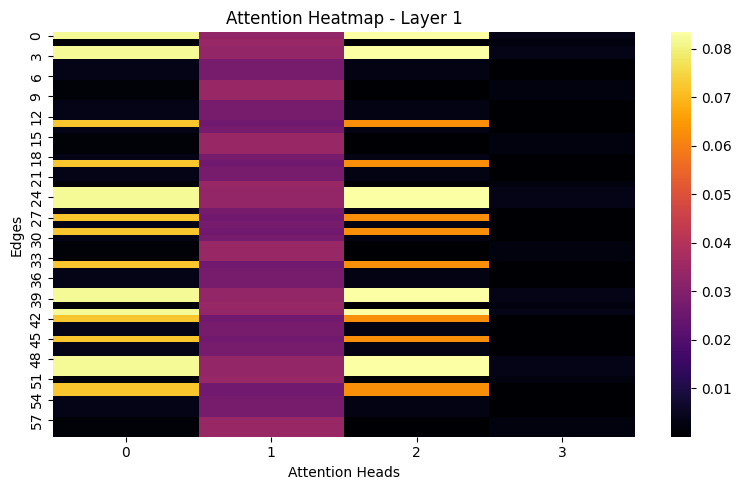

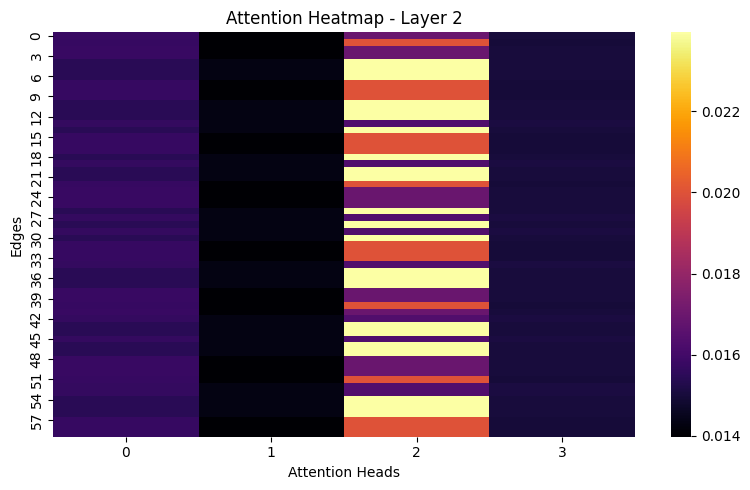

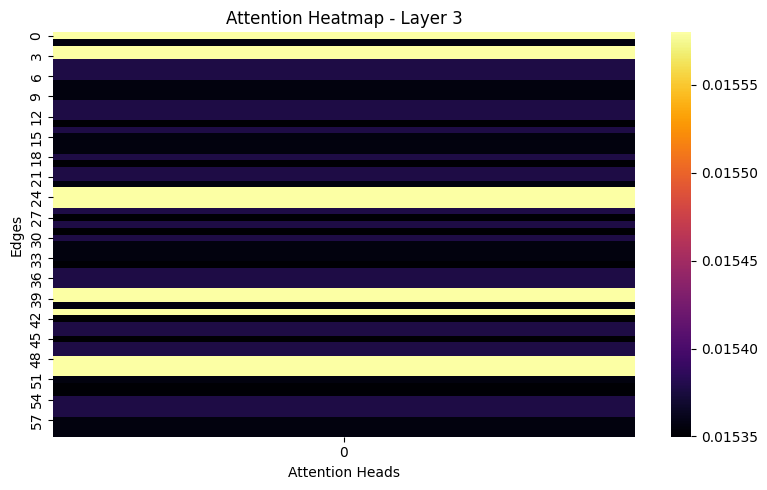

In [69]:
# ATTENTION HEATMAPS
for layer_idx, att in enumerate(attentions):

    edge_idx, alpha = att

    alpha = alpha.detach().cpu().numpy()

    plt.figure(figsize=(8, 5))

    sns.heatmap(
        alpha[:60],
        cmap="inferno"
    )

    plt.title(f"Attention Heatmap - Layer {layer_idx+1}")

    plt.xlabel("Attention Heads")
    plt.ylabel("Edges")

    plt.tight_layout()
    plt.show()

In [70]:
# COMPUTE EDGE IMPORTANCE
# USE FINAL GAT LAYER
edge_index, alpha = attentions[-1]

# average attention across heads
edge_scores = alpha.mean(dim=1).detach().cpu().numpy()

print("Number of edges:", len(edge_scores))

Number of edges: 520


ValueError: Invalid RGBA argument: np.float32(0.0155798)

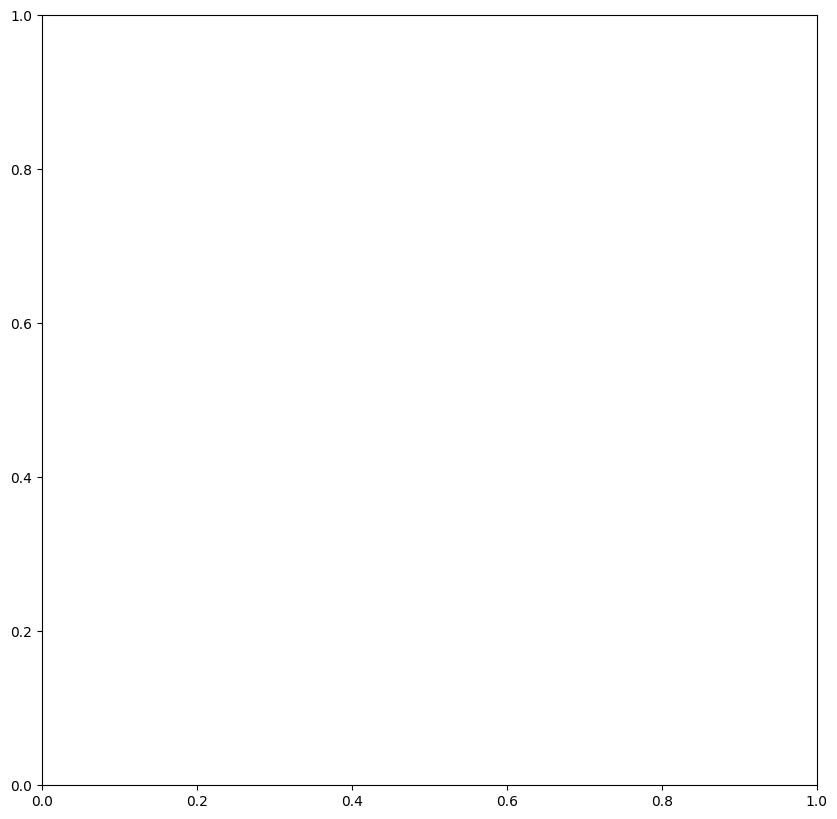

In [71]:
G = to_networkx(
    sample_data.cpu(),
    to_undirected=True
)

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42)

edges = nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_scores,
    edge_cmap=plt.cm.plasma,
    width=2
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color='lightblue',
    node_size=100
)

plt.colorbar(edges, label="Attention Importance")

plt.title("Important Atomic Bonds")

plt.axis("off")

plt.show()

In [72]:
num_nodes = sample_data.num_nodes

node_scores = np.zeros(num_nodes)

edge_index_np = edge_index.cpu().numpy()

for i in range(edge_index_np.shape[1]):

    src = edge_index_np[0, i]
    dst = edge_index_np[1, i]

    score = edge_scores[i]

    node_scores[src] += score
    node_scores[dst] += score

# normalize
node_scores = node_scores / node_scores.max()

print("Node importance scores:")
print(node_scores[:20])

Node importance scores:
[1.         0.99999908 0.99999939 0.99999918 0.99870916 0.99870968
 0.99870918 0.9987092 ]


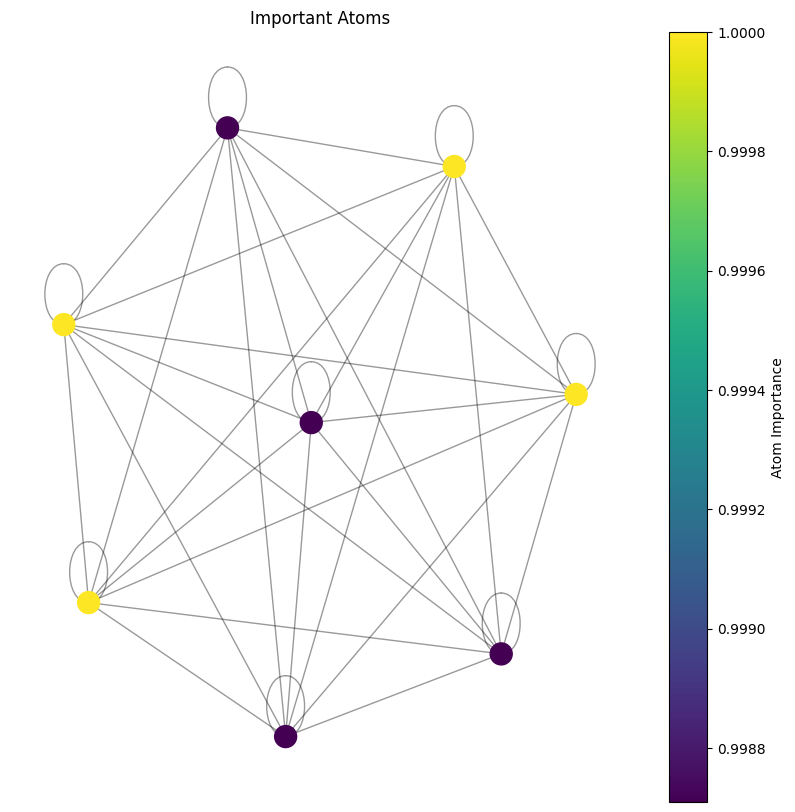

In [73]:
plt.figure(figsize=(10, 10))

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_scores,
    cmap=plt.cm.viridis,
    node_size=250
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.4
)

plt.colorbar(nodes, label="Atom Importance")

plt.title("Important Atoms")

plt.axis("off")

plt.show()

In [74]:
top_k = 10

top_indices = np.argsort(node_scores)[-top_k:]

print("Top important atom indices:")
print(top_indices)

Top important atom indices:
[4 6 7 5 1 3 2 0]


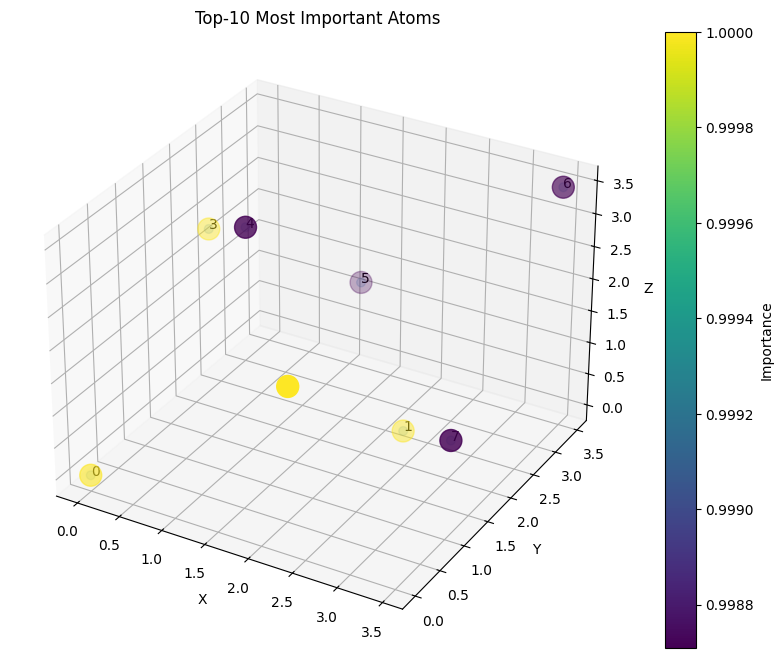

In [76]:
coords = sample_data.pos.cpu().numpy()

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# ALL ATOMS
ax.scatter(
    coords[:, 0],
    coords[:, 1],
    coords[:, 2],
    alpha=0.15,
    s=40
)


# IMPORTANT ATOMS

important_coords = coords[top_indices]

sc = ax.scatter(
    important_coords[:, 0],
    important_coords[:, 1],
    important_coords[:, 2],
    c=node_scores[top_indices],
    s=250
)

# labels
for i, idx in enumerate(top_indices):

    ax.text(
        important_coords[i, 0],
        important_coords[i, 1],
        important_coords[i, 2],
        str(idx),
        fontsize=10
    )

plt.colorbar(sc, label="Importance")

ax.set_title("Top-10 Most Important Atoms")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [60]:
sample_data = test_dataset[0].to(device)

gat_model.eval()

CharlesGAT(
  (node_emb): Linear(in_features=5, out_features=128, bias=True)
  (global_emb): Linear(in_features=14, out_features=128, bias=True)
  (gat1): GATConv(128, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 128, heads=1)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [61]:
explainer = Explainer(
    model=gat_model,

    algorithm=GNNExplainer(
        epochs=200
    ),

    explanation_type='model',

    node_mask_type='attributes',

    edge_mask_type='object',

    model_config=ModelConfig(
        mode='binary_classification',
        task_level='graph',
        return_type='raw'
    )
)

In [43]:
# ATTENTION WEIGHTS

gat_model.eval()

sample_data = test_dataset[0].to(device)

with torch.no_grad():

    out, attentions = gat_model(
        sample_data,
        return_attention=True
    )

print("Prediction probability:")
print(torch.sigmoid(out).item())

print("\nAttention layer information:")

for i, att in enumerate(attentions):

    edge_idx, alpha = att

    print(f"\nLayer {i+1}")

    print("Edge index shape:", edge_idx.shape)
    print("Attention shape:", alpha.shape)

    print("Sample attention values:")
    print(alpha[:10])

Prediction probability:
0.03530127927660942

Attention layer information:

Layer 1
Edge index shape: torch.Size([2, 132])
Attention shape: torch.Size([132, 4])
Sample attention values:
tensor([[5.6320e-02, 5.2428e-02, 8.6743e-10, 9.4135e-03],
        [6.9027e-02, 5.0596e-02, 2.2998e-09, 9.2998e-03],
        [1.1797e-01, 3.6240e-02, 1.9445e-05, 2.7704e-02],
        [1.3750e-01, 5.0646e-02, 2.7710e-04, 1.0626e-01],
        [1.1797e-01, 3.6240e-02, 1.9445e-05, 2.7704e-02],
        [1.1797e-01, 3.6240e-02, 1.9445e-05, 2.7704e-02],
        [5.6320e-02, 5.2428e-02, 8.6743e-10, 9.4135e-03],
        [1.3750e-01, 5.0646e-02, 2.7710e-04, 1.0626e-01],
        [6.9027e-02, 5.0596e-02, 2.2998e-09, 9.2998e-03],
        [1.1797e-01, 3.6240e-02, 1.9445e-05, 2.7704e-02]], device='cuda:0')

Layer 2
Edge index shape: torch.Size([2, 132])
Attention shape: torch.Size([132, 4])
Sample attention values:
tensor([[0.0670, 0.0659, 0.0888, 0.0626],
        [0.0673, 0.0659, 0.0732, 0.0624],
        [0.0568, 0.054

# PySR

In [44]:
# BUILD FEATURE MATRIX FOR PySR

X_pysr = []
y_pysr = []

gat_model.eval()

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        probs = torch.sigmoid(gat_model(data))

        for i in range(data.u.shape[0]):

            X_pysr.append(
                data.u[i].cpu().numpy()
            )

            y_pysr.append(
                probs[i].item()
            )

X_pysr = np.array(X_pysr)
y_pysr = np.array(y_pysr)

print("Feature matrix:", X_pysr.shape)
print("Targets:", y_pysr.shape)

Feature matrix: (1451, 14)
Targets: (1451,)


In [45]:
# SYMBOLIC REGRESSION

pysr_model = PySRRegressor(

    niterations=20,

    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],

    unary_operators=[
        "sin",
        "cos",
        "exp",
        "log",
        "sqrt"
    ],

    populations=20,

    maxsize=20,

    model_selection="best",

    loss="loss(x, y) = (x - y)^2"
)

pysr_model.fit(X_pysr, y_pysr)

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 3.610e+03
Progress: 22 / 400 total iterations (5.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.600e-01  0.000e+00  y = 0.4493
5           1.423e-01  2.936e-02  y = sin(sin(exp(sin(x₁₂))))
6           1.345e-01  5.607e-02  y = sin(sin(sin(exp(sin(x₁₂)))))
7           1.080e-01  2.199e-01  y = sin(sin(sin(0.85517 - sin(x₁₀))))
8           9.713e-02  1.058e-01  y = sin(sin(sin(0.65609 - sin(sin(x₁₀)))))
9           9.172e-02  5.724e-02  y = sin(sin(sin(0.65609 - sin(sin(sin(x₁₀))))))
10          8.802e-02  4.121e-02  y = sin(sin(sin(0.58891 - sin(sin(sin(sin(x₁₀)))))))
14          6.592e-02  7.229e-02  y = sin(sin(sin(cos(sin(x₈)) / exp(exp(x₁₀))) / exp(sin(x₁...
                                      ₀))))
16          5.873e-02  5.769e-02  

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          0.4493046   
	1        0.024970                              cos(x13) * 0.62871873   
	2        0.559666                      (1.7570196 - x10) * 0.2628216   
	3  >>>>  0.390644                 exp(x10 * -1.4217916) * 0.25405386   
	4        0.056437            sin(exp((x10 * -3.3001962) - 2.590062))   
	5        0.060049        sin(exp(exp(x10 * -1.4473579) - 3.0756714))   
	6        0.002870  sin(sin(exp(exp(x10 * -1.87025) - 4.0571747)) ...   
	7        0.007898  sin(exp(sin(exp(exp(x10 * -1.6745737) - 3.9556...   
	8        0.000561  exp((((x10 * -0.60570353) - x10) - -0.5715602)...   
	
	       loss  complexity  
	0  0.160009           1  
	1  0.148461           4  
	2  0.084830           5  
	3  0.057398           6  
	4  0.054248           7  
	5  0.051087           8  
	6  0.050649          11  
	7  0.050250          12  
	8  0.050025          20  
]

  - outputs/20260509_122744_ZEkT28/hall_of_fame.csv


In [46]:
# BEST DISCOVERED EQUATION

print(pysr_model)

print("\nBest Equation:")
print(pysr_model.get_best())

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          0.4493046   
	1        0.024970                              cos(x13) * 0.62871873   
	2        0.559666                      (1.7570196 - x10) * 0.2628216   
	3  >>>>  0.390644                 exp(x10 * -1.4217916) * 0.25405386   
	4        0.056437            sin(exp((x10 * -3.3001962) - 2.590062))   
	5        0.060049        sin(exp(exp(x10 * -1.4473579) - 3.0756714))   
	6        0.002870  sin(sin(exp(exp(x10 * -1.87025) - 4.0571747)) ...   
	7        0.007898  sin(exp(sin(exp(exp(x10 * -1.6745737) - 3.9556...   
	8        0.000561  exp((((x10 * -0.60570353) - x10) - -0.5715602)...   
	
	       loss  complexity  
	0  0.160009           1  
	1  0.148461           4  
	2  0.084830           5  
	3  0.057398           6  
	4  0.054248           7  
	5  0.051087           8  
	6  0.050649          11  
	7  0.050250          1

In [47]:
# Feature names
feature_names = [
    "spacegroup_number",
    "number_of_atoms",
    "a",
    "b",
    "c",
    "alpha",
    "beta",
    "gamma",
    "Z",
    "electronegativity",
    "band_gap",
    "volume",
    "density",
    "n_elements"
]

for i, name in enumerate(feature_names):
    print(f"x{i} -> {name}")

x0 -> spacegroup_number
x1 -> number_of_atoms
x2 -> a
x3 -> b
x4 -> c
x5 -> alpha
x6 -> beta
x7 -> gamma
x8 -> Z
x9 -> electronegativity
x10 -> band_gap
x11 -> volume
x12 -> density
x13 -> n_elements


# GNNEXPLAINER INTERPRETABILITY

In [ ]:
from torch_geometric.explain.config import ModelConfig

In [48]:
# Wrapp the CharlesCGCNN model

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, edge_attr=None, u=None, batch=None):
        # Reconstruct Data object Exactly like training
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr
        )

        # Add global features
        if u is not None:
            data.u = u

        # Batch handling
        if batch is None:
            data.batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        else:
            data.batch = batch

        return self.model(data)

In [49]:
# Initialize wrapped model
wrapped_model = CGCNNWrapper(model)
wrapped_model.eval()

NameError: name 'CGCNNWrapper' is not defined

In [50]:
# Setup Explainer

wrapped_model = WrappedModel(model)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='binary_classification',
        task_level='graph',
        return_type='raw'
    ),
)

NameError: name 'Explainer' is not defined

In [ ]:
# Run GNNExplainer
explanation = explainer(
    x=data.x,
    edge_index=data.edge_index,
    edge_attr=data.edge_attr,
    u=data.u
)

In [ ]:
# Extract Data
node_mask = explanation.node_mask.detach().cpu().numpy()
edge_mask = explanation.edge_mask.detach().cpu().numpy()

pos = data.pos.cpu().numpy()
edge_index = data.edge_index.cpu().numpy()

In [ ]:
# convert node mask
# Convert [num_nodes, num_features] -[num_nodes]
if len(node_mask.shape) == 2:
    node_mask = node_mask.mean(axis=1)

# Normalize
node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-8)
edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-8)

In [ ]:
# prepare 2d positions
pos_2d = pos[:, :2]

In [ ]:
# top view plot
plt.figure(figsize=(6,5))

sc = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=node_mask,
    s=200,
    cmap='coolwarm'
)

plt.colorbar(sc)
plt.title("Atom Importance (Top View)")
plt.show()

In [ ]:
# node importance
plt.figure(figsize=(6,5))

sc = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=node_mask,
    s=200,
    cmap='viridis'
)

plt.colorbar(sc)
plt.title("Node Importance (GNNExplainer)")
plt.show()

In [ ]:
plt.figure(figsize=(6,5))

# edges
for i in range(edge_index.shape[1]):
    src = edge_index[0, i]
    dst = edge_index[1, i]

    plt.plot(
        [pos_2d[src, 0], pos_2d[dst, 0]],
        [pos_2d[src, 1], pos_2d[dst, 1]],
        color='gray',
        alpha=0.3
    )

# nodes
sc = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=node_mask,
    s=200,
    cmap='viridis'
)

plt.colorbar(sc)
plt.title("Graph + Node Importance")
plt.show()

In [ ]:
# Side view (X vs Z)

fig, ax = plt.subplots()

sc = ax.scatter(
    pos[:, 0], pos[:, 2],
    c=node_mask,
    s=300 * node_mask + 50,
    cmap='coolwarm'
)

ax.set_title("Atom Importance (Side View)")
ax.set_xlabel("X")
ax.set_ylabel("Z")

plt.colorbar(sc, ax=ax)
plt.show()

In [ ]:
# Importance distribution
fig, ax = plt.subplots()

ax.hist(node_mask, bins=10, color='violet', edgecolor='black')

ax.set_title("Atom Importance Distribution")
ax.set_xlabel("Importance")
ax.set_ylabel("Count")

plt.show()

In [ ]:
# edge importance
fig, ax = plt.subplots()

edge_mask = explanation.edge_mask.detach().cpu().numpy()

for i, (src, dst) in enumerate(data.edge_index.t().cpu().numpy()):
    x = [pos[src, 0], pos[dst, 0]]
    y = [pos[src, 1], pos[dst, 1]]

    ax.plot(
        x, y,
        color=plt.cm.coolwarm(edge_mask[i]),
        alpha=0.7
    )

ax.scatter(pos[:, 0], pos[:, 1], c=node_mask, cmap='coolwarm', s=100)

ax.set_title("Bond (Edge) Importance")

plt.show()


In [ ]:
# 3D plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pos[:, 0], pos[:, 1], pos[:, 2],
    c=node_mask,
    cmap='coolwarm',
    s=200 * node_mask + 50
)

ax.set_title("3D Structure with Importance")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

fig.colorbar(sc)
plt.show()